=
## часть 3
# Память


Опять будем смотреть рукомахательное количество информации но к другому вопросу - какая зависимоть связи по времени, насколько чат помнит предыдущее (если процесс близок к марковскому то будет помнить фиксированное количество предыдущих и дальше падать очень быстро связь) 

+проверим какой формы деревья ответов (можно же думать что это частично упорядоченное множесто, можно исследовать характерные его величины - типа длина максимальной цепи, средняя ширина и вот такое)

Импорты

In [29]:
#копипаст из предыдущего
import os
while not os.path.isdir("chats"): os.chdir("..")
import numpy as np, pandas as pd, seaborn as sns

df = pd.read_csv("chats/physics/df.csv", parse_dates=["ts"])
df = df[~df["is_bot"]].reset_index(drop=True)
cats = sorted(df["mega"].unique())
K = len(cats)


In [ ]:
df.iloc[0]

In [31]:
df["k"] = df["mega"].map({c: i for i, c in enumerate(cats)})
codes = df["k"].to_numpy()

In [32]:
codes[:20]

array([6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 5, 4, 4, 4, 4, 4, 3, 4, 4, 4])

In [33]:
{c: i for i, c in enumerate(cats)}

{'others': 0,
 'Баллы и апелляции': 1,
 'Логистика и быт': 2,
 'Мета': 3,
 'Оффтоп/болтовня': 4,
 'Поступление и подготовка': 5,
 'Разбор задач': 6}

## как далеко тянется память

идея:взять два сообщения на расстоянии d в ленте и измерить такую же взаимную информацию (KL дивергенцию между бернулевским процессом и наблюдаемой связью) - и это еще будет функция от d

Можно посмотреть на ассимптотику зависимости I(d)

+как мы поняли что есть маленький шум связанный,с дисперсией самого процесса бернули, можно просто посчитать и вычесть его

<Axes: >

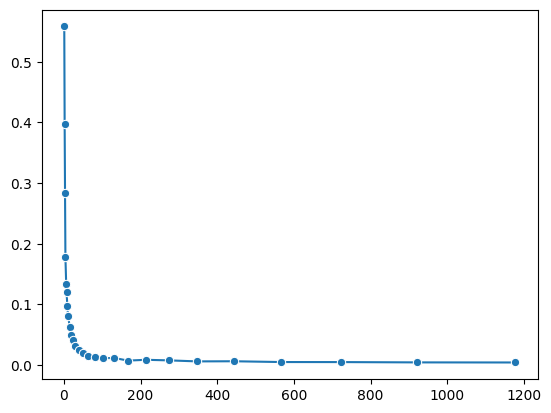

In [34]:
#gemini {
def table(a, b):
    T = np.zeros((K, K)); np.add.at(T, (a, b), 1); return T
def MI(a, b):
    M = table(a, b); P = M / M.sum()
    Pi, Pj = P.sum(1, keepdims=True), P.sum(0, keepdims=True)
    m = P > 0
    return (P[m] * np.log2(P[m] / (Pi * Pj)[m])).sum()   # KL(наблюдаемое || бернулли p_i*p_j)

deltas = np.unique(np.round(np.logspace(0, np.log10(len(codes)//100), 30)).astype(int))

I = []
for d in deltas:
    I.append(MI(codes[:-d], codes[d:]))     # связь тем на расстоянии d
I = np.array(I)
sns.lineplot(x=deltas, y=I, marker="o")
#}

### ожидаемо падает очень быстро, сообщение теряется в чате и тд

<Axes: >

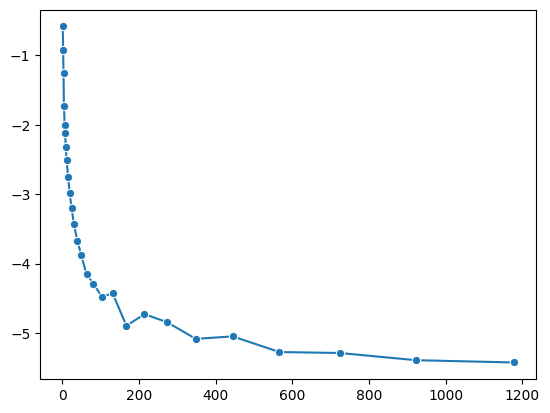

In [35]:
#логарифм
sns.lineplot(x=deltas, y=np.log(I), marker="o")

In [22]:
np.log(I)[-3:]

array([-5.28700326, -5.39543968, -5.42559768])

<Axes: >

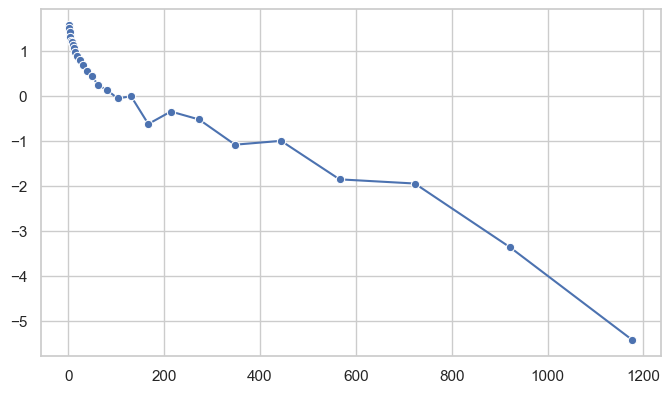

In [24]:
sns.lineplot(x=deltas, y=np.log(np.log(I) + 5.43), marker="o")

In [25]:
#похоже ли на прямую????

<Axes: >

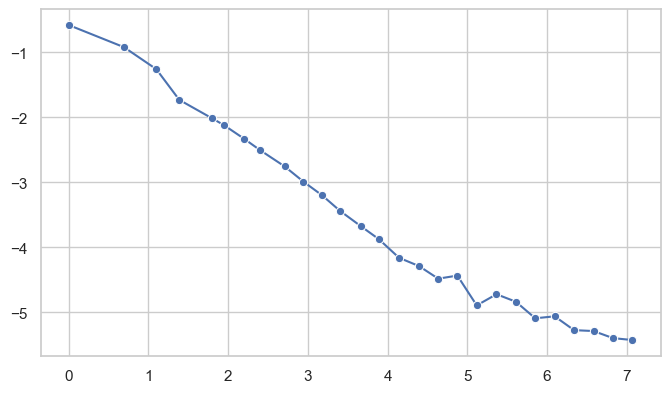

In [26]:
sns.lineplot(x=np.log(deltas), y=np.log(I), marker="o")

In [ ]:
#вот это грамотно

In [27]:
#посчитаем коэфициент

k, b = np.polyfit(np.log(deltas), np.log(I), 1)
print(k, b)

-0.7302880080499937 -0.7639990795877946


In [30]:
1-0.73

0.27

## экспонента или степень?

то есть у нас log(d) = A + k * log(delta)

d = C * delta^k - степенная зависимость, k = -0.73 - примерно обратная пропорционалность

In [ ]:
#причем кстати прикольно что степено одинаковая на всех масштабах d, то есть от 10 до тысяч
#надо подумать связано ли это со свойствами KL дивергенции

##  в близи на сколько шагов нужно помнить?

всм какое характерное число предыдущих сообщений дают существенную часть информации темы (типа интеграл от количества информации по d)

ИТОГО измерить сколько бит добавляет знание ЕЩЕ одного предыдущего сообщения, где добавка
падает в ноль там можно остановиться (забить на хвосты - ИЛИ надо проверить что они не достаточно тяжелые!!!!!!)

оценка ручками:
I = C1 * d^k, Int(I) = C2 * d^(k+1) ~ d^0.27 - будет очень медленно ползти вверх неограниченно, то есть ряд расходится и память бесконечная (прикольно)


<Axes: >

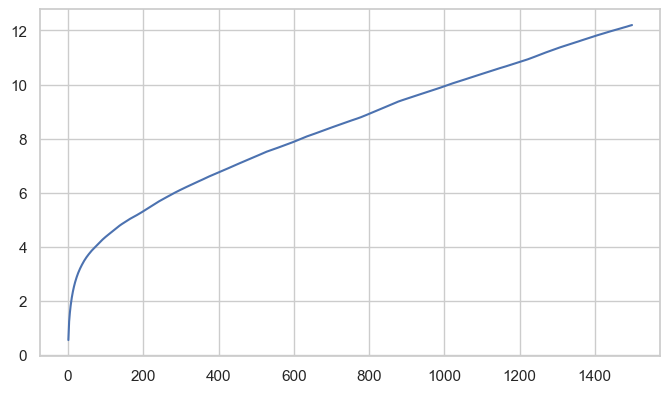

In [34]:
dd = np.arange(1, 1500)
Id = np.array([MI(codes[:-d], codes[d:]) for d in dd])
s = np.cumsum(Id)
sns.lineplot(x=dd, y=s)


<Axes: >

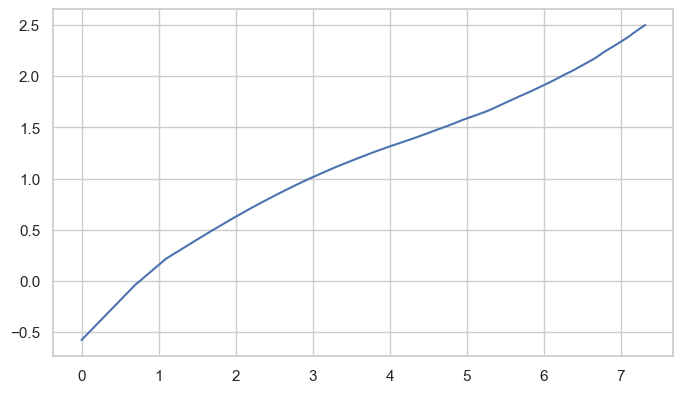

In [36]:
sns.lineplot(x=np.log(dd), y=np.log(S))


In [ ]:
np.polyfit(np.log(dd[50:]), np.log(S[50:]), 1)[0] #k+1

np.float64(0.38216006990550627)

In [ ]:
#кстати странно, у нас получилась небольшая ошибка в измерении k

## время возвращения темы

лемма Каца гласит что среднее время возвращения в состояние X - обратнопропорционально доле времени проводимому системой в этом состоянии

Можно взять одну тему и смотреть промежутки между ее появлениями
+надо смотреть именно на номера сообщений (то есть мы смотрим на строку где буква - тема) - тк есть провалы по времени и тд и тп

+посмотреть не только среднее но глянуть и распределение этого времени ожидания

In [ ]:
#посмотрим на топ 1
top = df["mega"].value_counts().index[0]
top

'Оффтоп/болтовня'

In [7]:
kt = cats.index(top)
kt

4

In [8]:
gaps = np.diff(np.where(codes == kt)[0])
gaps

array([1, 1, 1, ..., 1, 1, 1])

<Axes: ylabel='Count'>

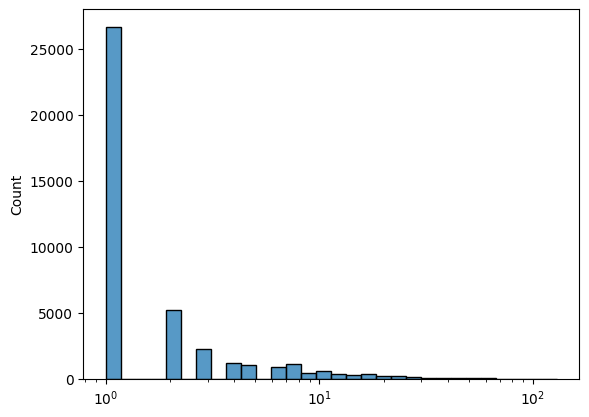

In [11]:
sns.histplot(gaps, log_scale=True, bins=30)

In [ ]:
#длинный хвост, те тема может не появляться подолгу и резко очередями спамить

In [20]:
dictik = {i: c for i, c in enumerate(cats)}
dictik2 = {c: i for i, c in enumerate(cats)}


In [18]:
dictik

{0: 'others',
 1: 'Баллы и апелляции',
 2: 'Логистика и быт',
 3: 'Мета',
 4: 'Оффтоп/болтовня',
 5: 'Поступление и подготовка',
 6: 'Разбор задач'}

In [ ]:
# по другим темам

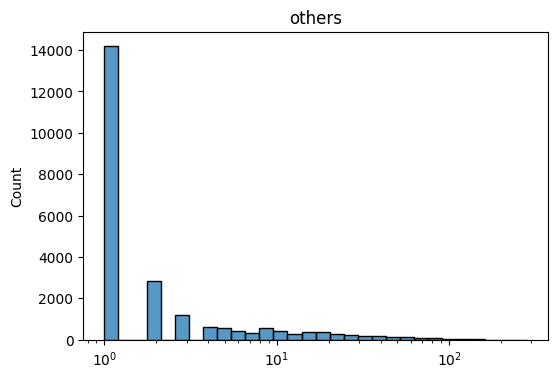

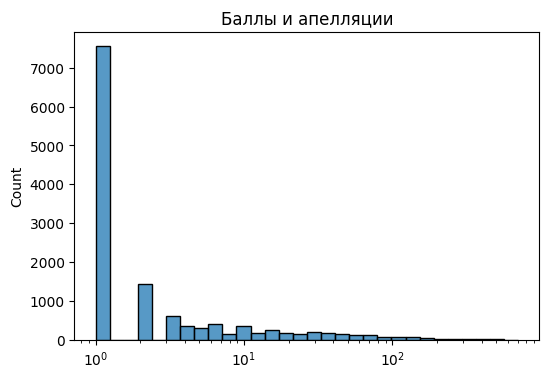

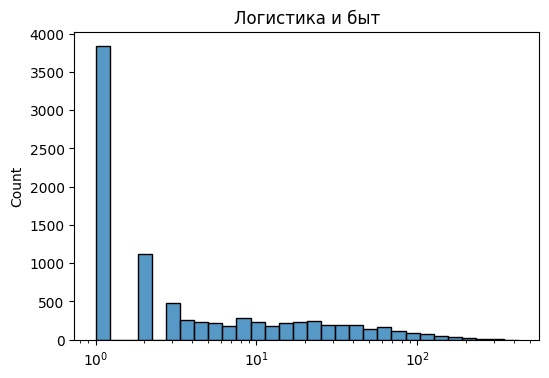

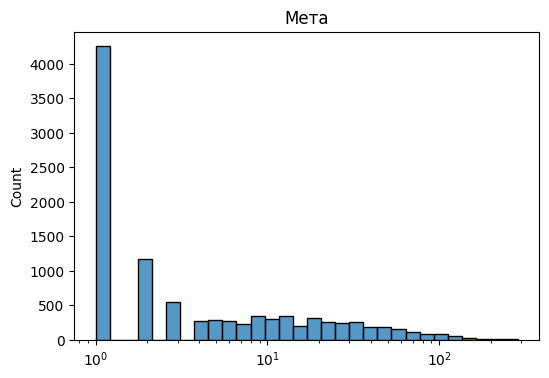

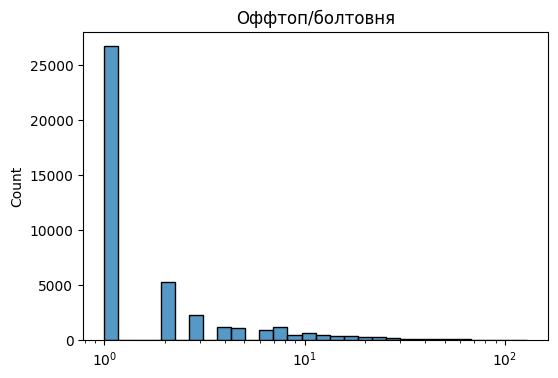

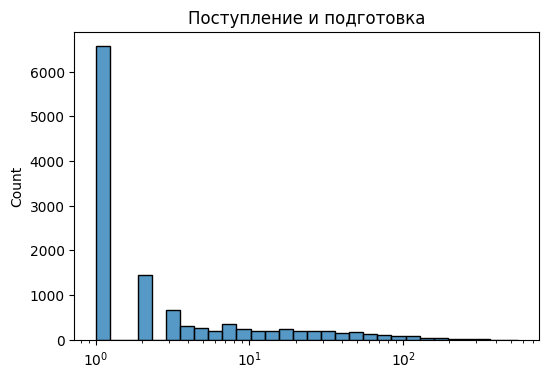

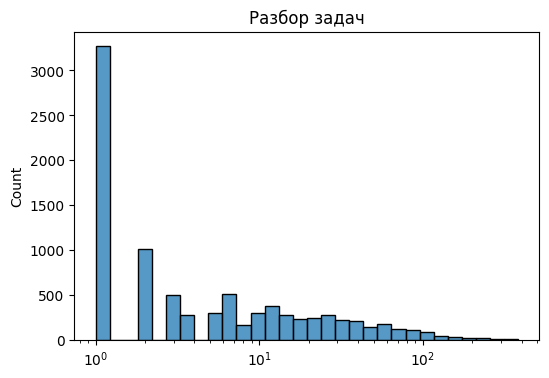

In [22]:
# gemini {

import matplotlib.pyplot as plt

for kt in list(cats):
    plt.figure(figsize=(6, 4)) # Создаем новую фигуру, чтобы графики не слипались
    sns.histplot(np.diff(np.where(codes == dictik2[kt])[0]), log_scale=True, bins=30)
    plt.title(kt)      # Берем лейбл из словаря и ставим наверх
    plt.show()                 # Отрисовываем текущий график перед переходом к следующему
#}

##### примерно есть одно и то же

еще удобно ввести метрику B = (σ - μ)/(σ + μ) по промежуткам:

типа σ = μ -> B=0, B>0 значит сообщения в основном идут пачками, B<0 более равномерно, по расписанию и делим на сумму чтоб нормированно чтоб было от -1 до 1 в среднем

In [23]:
def B(seq, k):
    g = np.diff(np.where(seq == k)[0]).astype(float)
    return (g.std() - g.mean()) / (g.std() + g.mean())

In [27]:
perm = np.random.permutation(codes)
rows = []

for k in range(K):
    rows.append({"tema": cats[k], "B": B(codes, k), "type": "real"})
    rows.append({"tema": cats[k], "B": B(perm, k), "type": "perm"})
rows = pd.DataFrame(rows)

rows

,tema,B,type
0,others,0.430766,real
1,others,-0.057664,perm
2,Баллы и апелляции,0.522471,real
3,Баллы и апелляции,-0.040042,perm
4,Логистика и быт,0.371896,real
5,Логистика и быт,-0.021512,perm
6,Мета,0.320048,real
7,Мета,-0.016114,perm
8,Оффтоп/болтовня,0.288397,real
9,Оффтоп/болтовня,-0.110572,perm


<Axes: xlabel='B', ylabel='tema'>

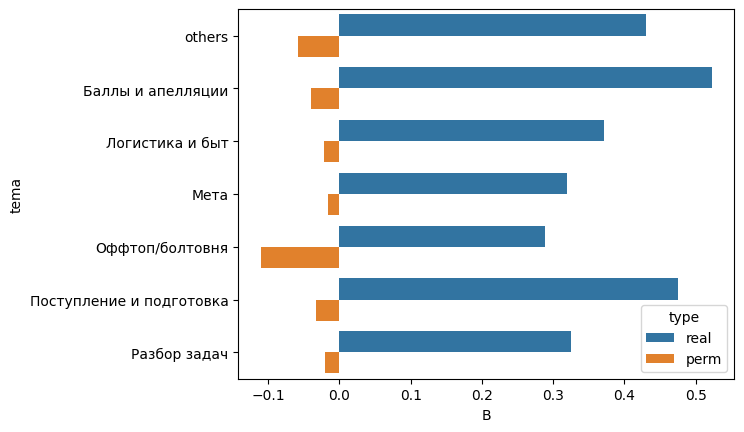

In [28]:
sns.barplot(data=rows, x="B", y="tema", hue="type")

##### понятно что у перестановочного должно быть близко к пуассоновскому или другому хорошему где среднее близко с дисперсией

#### А настоящие - в основном идут пачками (в распределении очень больной столб на нуле и длинный хвост)

## форма деревьев обсуждений

ответы делают деревья (тк каждое сообщение отвечает максимум на одно!)


In [42]:
parent = dict(zip(df["unit_id"], df["reply_to_unit"]))
ids = set(df["unit_id"])

roots = {}
for u in df["unit_id"]:
    x = u
    while parent[x] in ids:
        x = parent[x]
    roots[u] = x

In [43]:
roots

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 4,
 8: 8,
 9: 9,
 10: 10,
 11: 11,
 12: 12,
 13: 13,
 14: 14,
 15: 15,
 16: 16,
 17: 15,
 18: 15,
 19: 15,
 20: 2,
 21: 21,
 22: 2,
 23: 2,
 24: 2,
 25: 2,
 26: 2,
 27: 27,
 28: 28,
 29: 29,
 30: 30,
 31: 31,
 32: 32,
 33: 2,
 34: 29,
 35: 2,
 36: 2,
 37: 2,
 38: 2,
 39: 2,
 40: 2,
 41: 2,
 42: 2,
 43: 43,
 44: 2,
 45: 2,
 46: 2,
 47: 47,
 48: 2,
 49: 47,
 50: 47,
 51: 51,
 52: 51,
 53: 53,
 54: 53,
 55: 53,
 56: 56,
 57: 53,
 58: 58,
 59: 59,
 60: 60,
 61: 61,
 62: 62,
 63: 63,
 64: 63,
 65: 65,
 66: 66,
 67: 65,
 68: 65,
 69: 69,
 70: 70,
 71: 69,
 72: 70,
 73: 70,
 74: 74,
 75: 70,
 76: 70,
 77: 70,
 78: 70,
 79: 70,
 80: 80,
 81: 80,
 82: 80,
 83: 83,
 84: 84,
 85: 80,
 86: 80,
 87: 87,
 88: 83,
 89: 80,
 90: 87,
 91: 83,
 92: 70,
 93: 87,
 94: 80,
 95: 83,
 96: 87,
 97: 97,
 98: 98,
 99: 87,
 100: 87,
 101: 101,
 102: 87,
 103: 103,
 104: 87,
 105: 87,
 106: 87,
 107: 107,
 108: 108,
 109: 109,
 110: 110,
 111: 111,
 112: 112,
 

In [44]:
sizes = pd.Series(roots).value_counts()
sizes

100206    51
86548     51
23534     50
372       49
6950      46
          ..
53954      1
53957      1
53958      1
53959      1
120124     1
Name: count, Length: 52828, dtype: int64

In [45]:
vc = sizes.value_counts()
vc

count
1     32228
2      8899
3      3951
4      2353
5      1453
6       971
7       659
8       492
9       381
10      283
11      197
12      188
13      146
14      123
15       81
17       58
16       57
18       46
19       45
20       33
21       30
22       27
24       20
25       12
23       12
27       10
26        8
28        7
31        6
35        5
41        5
29        5
30        5
32        4
33        4
38        4
44        3
42        3
46        2
51        2
40        2
39        2
34        2
37        1
45        1
49        1
50        1
Name: count, dtype: int64

<Axes: xlabel='count'>

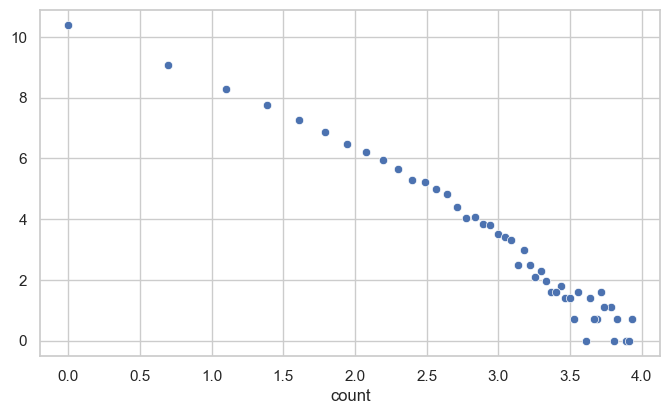

In [ ]:
sns.scatterplot(x=np.log(vc.index), y=np.log(vc.values))

In [49]:
#распределение количества тредов определенной длины от их длины (в лог шкале)
#то есть сильно большая (на 32к!) есть но остальные на порядки меньше и всреднем все маленькие

давайте померим насколько параллельны эти истории - если взять 2 случайных сообщения (либо во времени чтоб они близко были) - какая вероятность что они будут сравнимы?

ну мы будем брать 2 случайных сообщения в некотором окне длины t и можно как раз померить зависимость этой вероятности от t

In [51]:
N = len(df)
N

117775

In [54]:
pos = dict(zip(df["unit_id"], range(N)))
pos

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 8: 8,
 9: 9,
 10: 10,
 11: 11,
 12: 12,
 13: 13,
 14: 14,
 15: 15,
 16: 16,
 17: 17,
 18: 18,
 19: 19,
 20: 20,
 21: 21,
 22: 22,
 23: 23,
 24: 24,
 25: 25,
 26: 26,
 27: 27,
 28: 28,
 29: 29,
 30: 30,
 31: 31,
 32: 32,
 33: 33,
 34: 34,
 35: 35,
 36: 36,
 37: 37,
 38: 38,
 39: 39,
 40: 40,
 41: 41,
 42: 42,
 43: 43,
 44: 44,
 45: 45,
 46: 46,
 47: 47,
 48: 48,
 49: 49,
 50: 50,
 51: 51,
 52: 52,
 53: 53,
 54: 54,
 55: 55,
 56: 56,
 57: 57,
 58: 58,
 59: 59,
 60: 60,
 61: 61,
 62: 62,
 63: 63,
 64: 64,
 65: 65,
 66: 66,
 67: 67,
 68: 68,
 69: 69,
 70: 70,
 71: 71,
 72: 72,
 73: 73,
 74: 74,
 75: 75,
 76: 76,
 77: 77,
 78: 78,
 79: 79,
 80: 80,
 81: 81,
 82: 82,
 83: 83,
 84: 84,
 85: 85,
 86: 86,
 87: 87,
 88: 88,
 89: 89,
 90: 90,
 91: 91,
 92: 92,
 93: 93,
 94: 94,
 95: 95,
 96: 96,
 97: 97,
 98: 98,
 99: 99,
 100: 100,
 101: 101,
 102: 102,
 103: 103,
 104: 104,
 105: 105,
 106: 106,
 107: 107,
 108: 108,
 109: 109,
 110: 110,

In [57]:
gaps = []
for u in df["unit_id"]:
    x = u
    while parent[x] in ids:
        x = parent[x]
        gaps.append(pos[u] - pos[x])
gaps = np.array(gaps)
gaps

array([3, 2, 1, ..., 5, 6, 7])

In [58]:
ts = np.unique(np.round(np.logspace(0, np.log10(N//5), 25)).astype(int))
frac = []
for t in ts:
    comp = (gaps <= t).sum()           # сравнимых пар в окне t
    total = N * t - t*(t+1)//2          # всего пар (i<j, j-i<=t)
    frac.append(comp / total)

In [67]:
frac[:3]

[np.float64(0.19071272097406897),
 np.float64(0.18346656930463984),
 np.float64(0.1501093209365514)]

<Axes: >

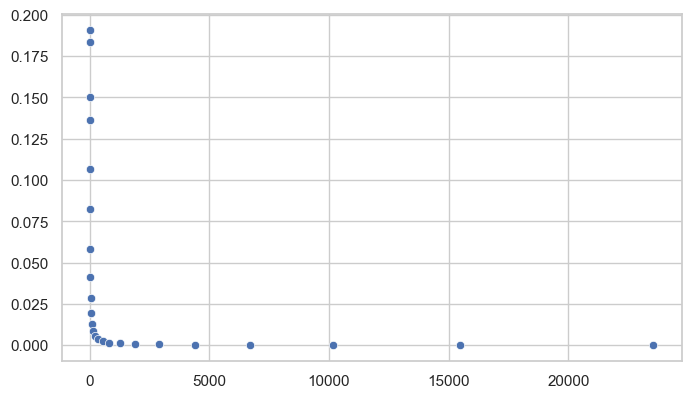

In [63]:
sns.scatterplot(x=ts, y=frac)

<Axes: >

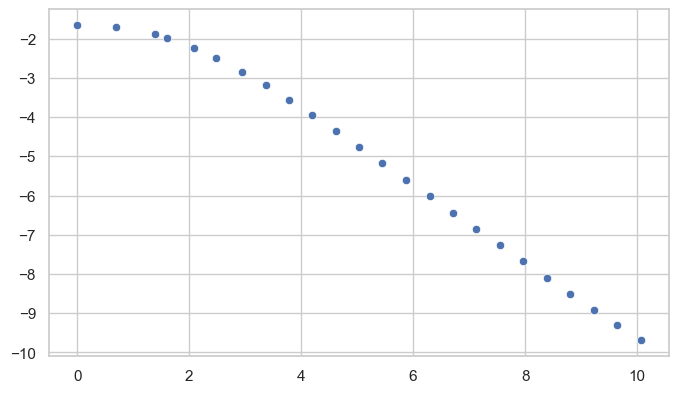

In [64]:
sns.scatterplot(x=np.log(ts), y=np.log(frac))

In [66]:
k, b = np.polyfit(np.log(ts), np.log(frac), 1)
print(k, b)

-0.8775614672207555 -0.5914338579446607


#### то есть frac ~ t ^ (-0.6)

## итоги по идеям

1. память степенная (I(d) ~ d ^ -0.7) - при практически всех d
2. нет характерного числа сообщений, которые сообщаяют информацию (ряд расходится)
3. все темы возвращаются пачками (B>0) - те же волны, что видели в части 1 (реальная дисперсия больше бернулевской теоретической)
4. много глубоких цепей ответов, но в основном короткие (количество также распределено по степенному закону от длины)
5. деревья ответов широкие (r ~ 1e-5 на всем чате), и по степенному закону ростет их ширина в зависимости от длины контекста